In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud

from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

df = pd.read_csv('netflix_titles.csv')
print("Размер набора данных:", df.shape)

Размер набора данных: (8807, 12)


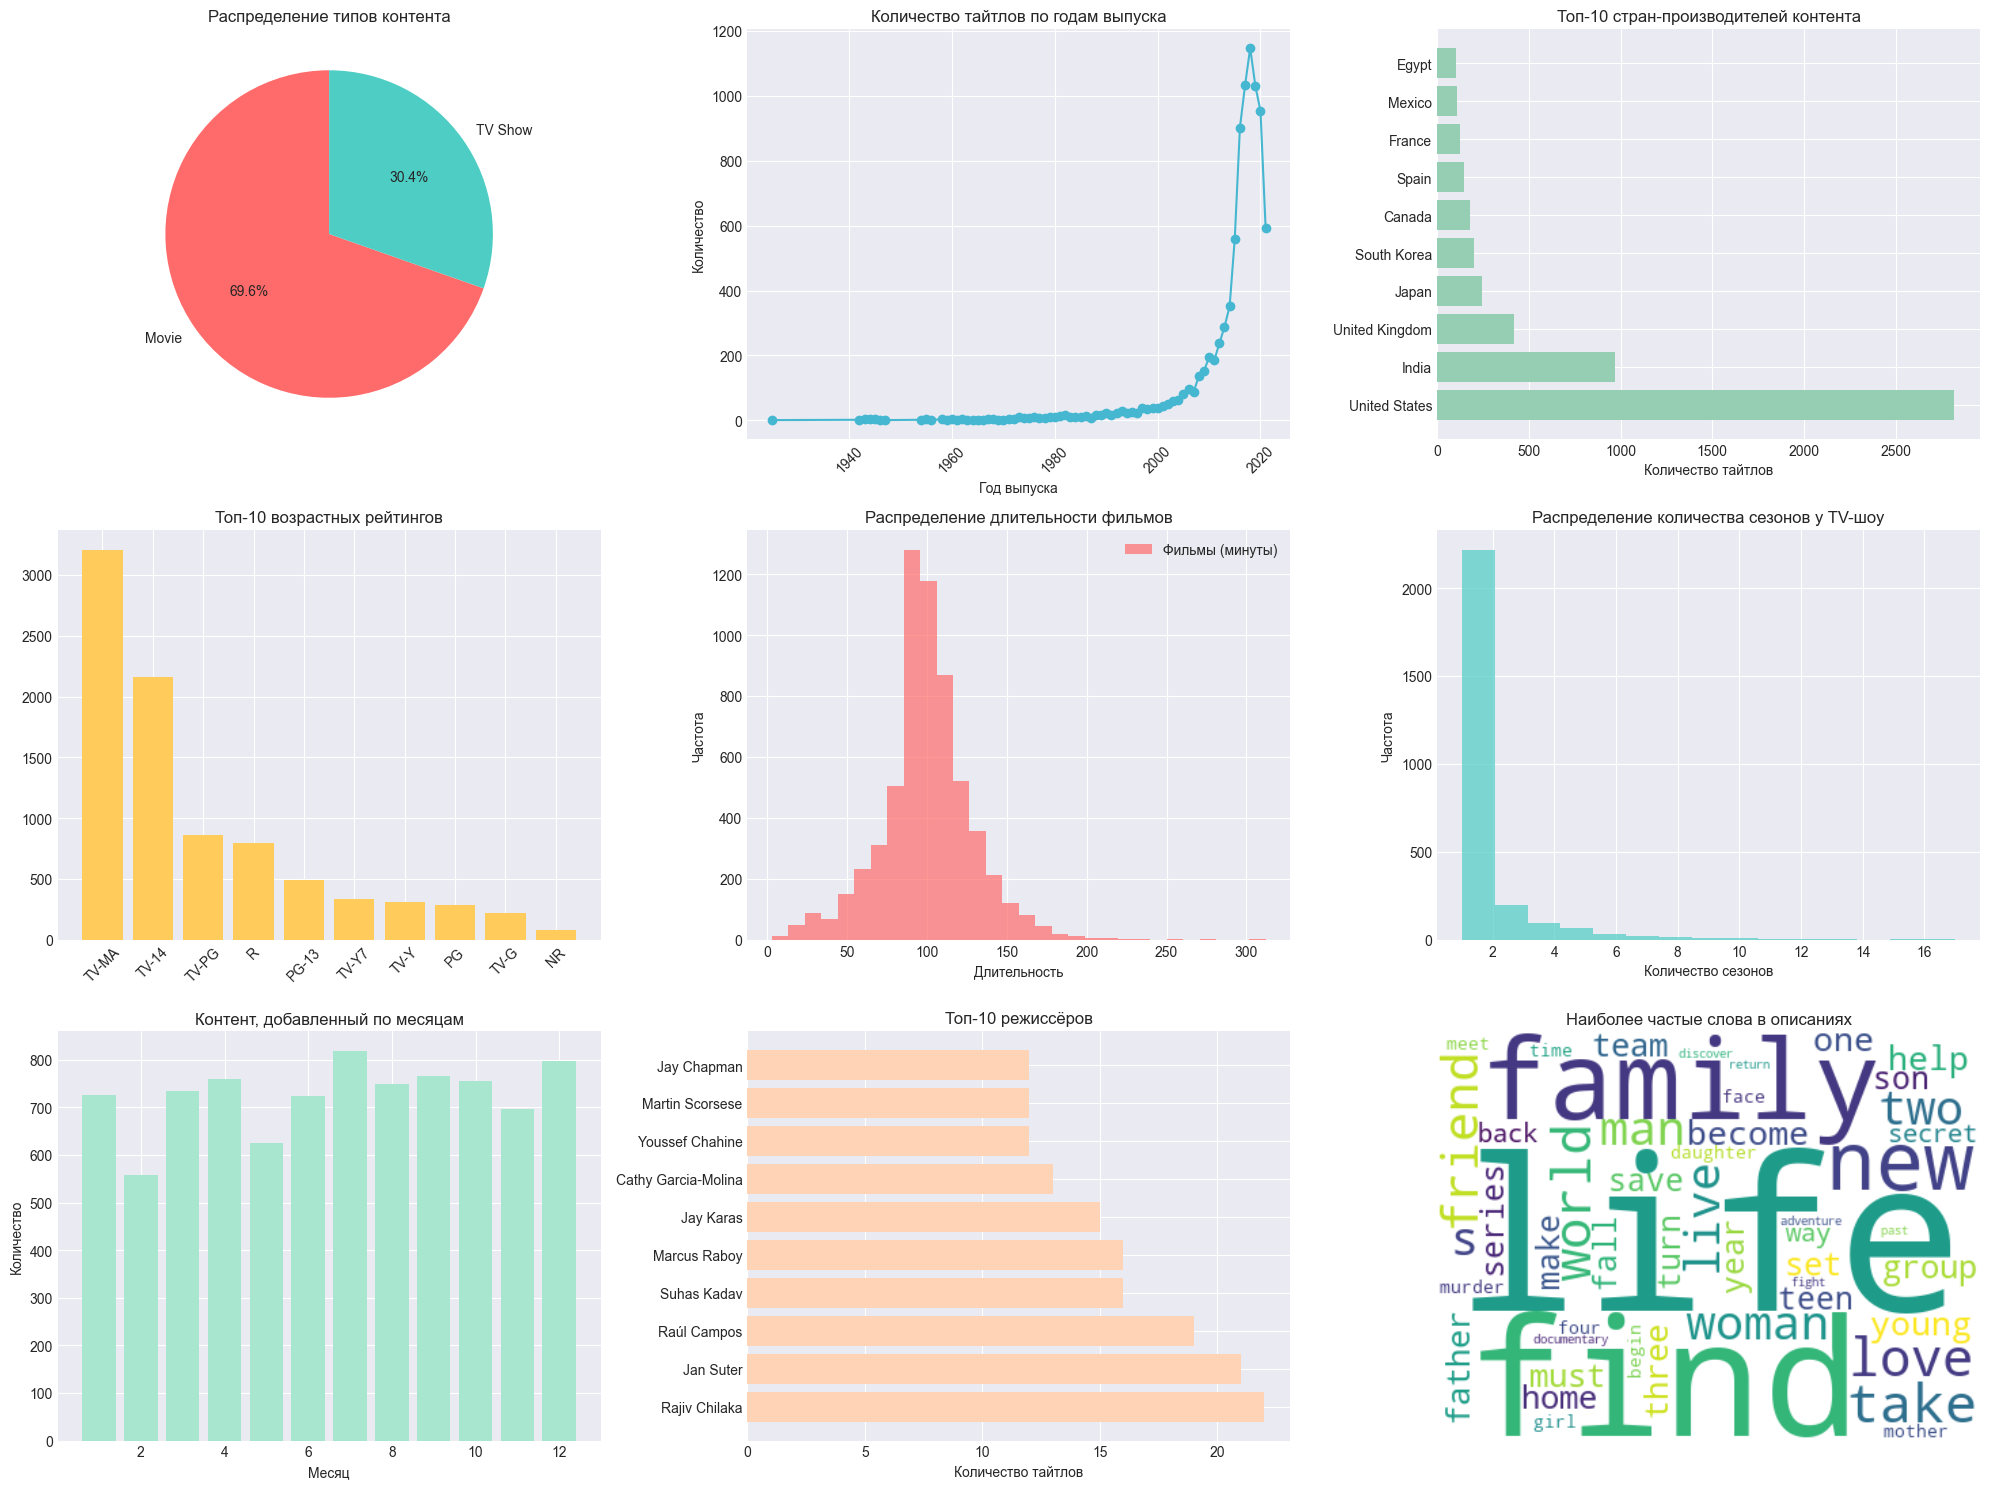

In [18]:
# EDA и ВИЗУАЛИЗАЦИИ 
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 1)
type_counts = df['type'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
        colors=['#ff6b6b', '#4ecdc4'], startangle=90)
plt.title('Распределение типов контента')

plt.subplot(3, 3, 2)
year_added = df['release_year'].value_counts().sort_index()
plt.plot(year_added.index, year_added.values, marker='o', color='#45b7d1')
plt.xlabel('Год выпуска')
plt.ylabel('Количество')
plt.title('Количество тайтлов по годам выпуска')
plt.xticks(rotation=45)

plt.subplot(3, 3, 3)
countries = df['country'].value_counts().head(10)
plt.barh(countries.index, countries.values, color='#96ceb4')
plt.xlabel('Количество тайтлов')
plt.title('Топ-10 стран-производителей контента')

plt.subplot(3, 3, 4)
rating_counts = df['rating'].value_counts().head(10)
plt.bar(rating_counts.index, rating_counts.values, color='#ffcc5c')
plt.xticks(rotation=45)
plt.title('Топ-10 возрастных рейтингов')

plt.subplot(3, 3, 5)
movies = df[df['type'] == 'Movie']
movies_duration = movies['duration'].str.extract(r'(\d+)').astype(float)
plt.hist(movies_duration.dropna(), bins=30, alpha=0.7, label='Фильмы (минуты)', color='#ff6b6b')
plt.xlabel('Длительность')
plt.ylabel('Частота')
plt.title('Распределение длительности фильмов')
plt.legend()

plt.subplot(3, 3, 6)
tv_shows = df[df['type'] == 'TV Show']
tv_seasons = tv_shows['duration'].str.extract(r'(\d+)').astype(float)
plt.hist(tv_seasons.dropna(), bins=15, alpha=0.7, color='#4ecdc4')
plt.xlabel('Количество сезонов')
plt.ylabel('Частота')
plt.title('Распределение количества сезонов у TV-шоу')

plt.subplot(3, 3, 7)
if 'date_added' in df.columns:
    df['date_added_parsed'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['month_added'] = df['date_added_parsed'].dt.month
    month_counts = df['month_added'].value_counts().sort_index()
    plt.bar(month_counts.index, month_counts.values, color='#a8e6cf')
    plt.xlabel('Месяц')
    plt.ylabel('Количество')
    plt.title('Контент, добавленный по месяцам')

plt.subplot(3, 3, 8)
directors = df['director'].str.split(', ').explode().value_counts().head(10)
plt.barh(directors.index, directors.values, color='#ffd3b6')
plt.xlabel('Количество тайтлов')
plt.title('Топ-10 режиссёров')

plt.subplot(3, 3, 9)
if 'description' in df.columns:
    text = ' '.join(df['description'].dropna().astype(str))
    wordcloud = WordCloud(width=400, height=300, background_color='white', 
                          max_words=50, colormap='viridis').generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Наиболее частые слова в описаниях')

plt.tight_layout()
plt.show()

In [19]:
# ОЧИСТКА ДАННЫХ

df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

for col in ['director', 'cast', 'country']:
    df_clean[col] = df_clean[col].fillna('Unknown')

df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].mode()[0])
df_clean['date_added'] = df_clean['date_added'].ffill()

movies_mask = df_clean['type'] == 'Movie'
tv_mask = df_clean['type'] == 'TV Show'
df_clean.loc[movies_mask, 'duration'] = df_clean.loc[movies_mask, 'duration'].fillna('90 min')
df_clean.loc[tv_mask, 'duration'] = df_clean.loc[tv_mask, 'duration'].fillna('1 Season')

df_clean['duration_numeric'] = df_clean['duration'].str.extract(r'(\d+)').astype(float)
movies_data = df_clean[df_clean['type'] == 'Movie']
upper_limit = movies_data['duration_numeric'].quantile(0.99)
df_clean.loc[(df_clean['type'] == 'Movie') & (df_clean['duration_numeric'] > upper_limit), 'duration_numeric'] = upper_limit

valid_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'PG', 'TV-Y', 'G', 'NR', 'TV-G']
df_clean = df_clean[df_clean['rating'].isin(valid_ratings)]
df_clean = df_clean[(df_clean['release_year'] >= 1920) & (df_clean['release_year'] <= 2025)]

print(f"После очистки: {len(df_clean)} строк")

После очистки: 8792 строк


In [20]:
#СОЗДАНИЕ ПРИЗНАКОВ
if 'date_added' in df_clean.columns:
    df_clean['date_added_parsed'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
    df_clean['year_added'] = df_clean['date_added_parsed'].dt.year
    df_clean['month_added'] = df_clean['date_added_parsed'].dt.month

df_clean['content_age'] = 2026 - df_clean['release_year']
df_clean['num_countries'] = df_clean['country'].str.split(', ').str.len()
df_clean['num_directors'] = df_clean['director'].str.split(', ').str.len().replace(0, 1)
df_clean['num_cast'] = df_clean['cast'].str.split(', ').str.len().replace(0, 1)
df_clean['title_length'] = df_clean['title'].str.len()
df_clean['title_word_count'] = df_clean['title'].str.split().str.len()
df_clean['num_genres'] = df_clean['listed_in'].str.split(', ').str.len()

if 'date_added_parsed' in df_clean.columns:
    df_clean['weekend_release'] = df_clean['date_added_parsed'].dt.dayofweek.isin([5, 6]).astype(int)

In [21]:
# УДАЛЕНИЕ ПРОБЛЕМНЫХ РЕЙТИНГОВ

ratings_only_in_movies = ['PG', 'PG-13', 'G', 'TV-Y', 'TV-Y7', 'TV-G', 'NR']
for rating in df_clean['rating'].unique():
    movies_with_rating = ((df_clean['type'] == 'Movie') & (df_clean['rating'] == rating)).sum()
    tv_with_rating = ((df_clean['type'] == 'TV Show') & (df_clean['rating'] == rating)).sum()
    if movies_with_rating > 0 and tv_with_rating == 0:
        ratings_only_in_movies.append(rating)

ratings_to_remove = list(set(ratings_only_in_movies))
df_clean_fixed = df_clean[~df_clean['rating'].isin(ratings_to_remove)]
print(f"Строк после удаления: {len(df_clean_fixed)}")

Строк после удаления: 7033


In [22]:
# ПОДГОТОВКА ДАННЫХ 

safe_features = [
    'release_year', 'content_age', 'num_countries', 'num_directors', 
    'num_cast', 'title_length', 'title_word_count', 'num_genres'
]

for feat in ['year_added', 'month_added', 'weekend_release']:
    if feat in df_clean_fixed.columns:
        safe_features.append(feat)

X = df_clean_fixed[safe_features].copy()
X['rating'] = df_clean_fixed['rating']

X = X.dropna()
y = df_clean_fixed.loc[X.index, 'type'].map({'Movie': 0, 'TV Show': 1})

X_encoded = pd.get_dummies(X, columns=['rating'], drop_first=True)
X_encoded = X_encoded.drop_duplicates()
y = y[X_encoded.index]

print(f"X форма: {X_encoded.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Movie: {sum(y_train==0)}, TV Show: {sum(y_train==1)}")


X форма: (6947, 14)
X_train: (5557, 14), X_test: (1390, 14)
Movie: 3851, TV Show: 1706


In [23]:
# БАЗОВАЯ МОДЕЛЬ

from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline (most frequent): {baseline_acc:.4f}")

Baseline (most frequent): 0.6928



Logistic Regression:
  Test Accuracy: 0.7115
  CV Mean: 0.7160 (+/- 0.0039)
  AUC-ROC: 0.7321

Decision Tree:
  Test Accuracy: 0.7094
  CV Mean: 0.7286 (+/- 0.0087)
  AUC-ROC: 0.7053

Random Forest:
  Test Accuracy: 0.7640
  CV Mean: 0.7551 (+/- 0.0068)
  AUC-ROC: 0.8202

Gradient Boosting:
  Test Accuracy: 0.7604
  CV Mean: 0.7544 (+/- 0.0097)
  AUC-ROC: 0.8158

KNN:
  Test Accuracy: 0.7223
  CV Mean: 0.7171 (+/- 0.0094)
  AUC-ROC: 0.7243

Naive Bayes:
  Test Accuracy: 0.5547
  CV Mean: 0.5505 (+/- 0.0256)
  AUC-ROC: 0.7226

СРАВНЕНИЕ МОДЕЛЕЙ

                     accuracy   cv_mean    cv_std       auc
Random Forest        0.764029  0.755083  0.006849  0.820244
Gradient Boosting    0.760432  0.754361  0.009718  0.815792
KNN                  0.722302  0.717111  0.009407  0.724264
Logistic Regression  0.711511  0.716033  0.003936  0.732075
Decision Tree        0.709353  0.728630  0.008703  0.705274
Naive Bayes          0.554676  0.550480  0.025594  0.722559


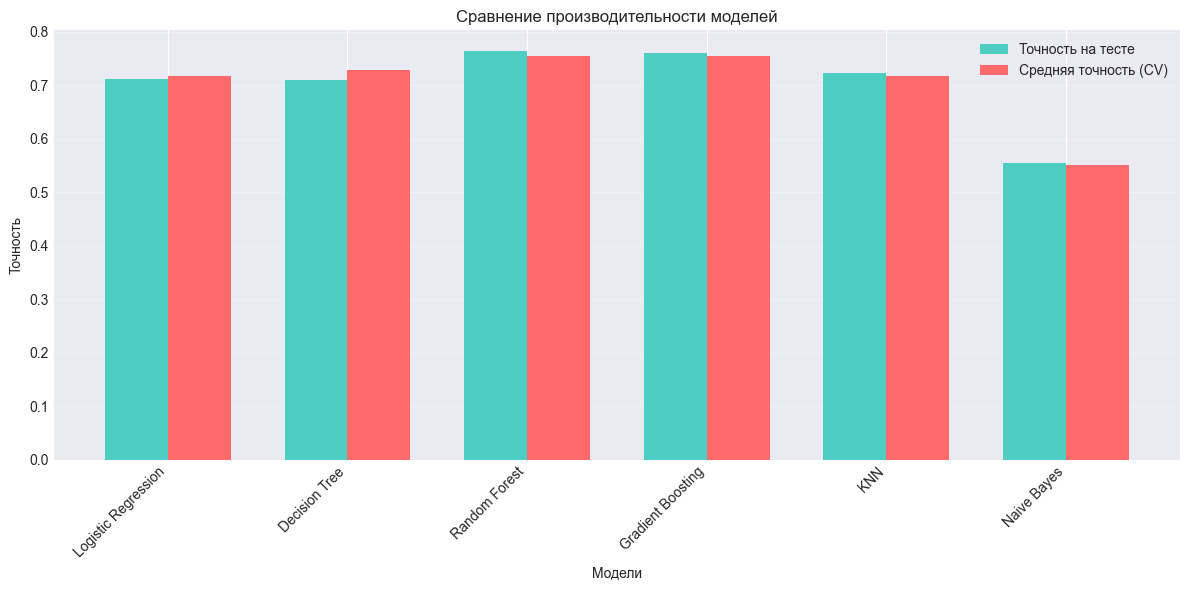

In [24]:
# ОБУЧЕНИЕ МОДЕЛЕЙ

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = {'accuracy': acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        results[name]['auc'] = roc_auc_score(y_test, y_proba)
    
    print(f"\n{name}:")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  CV Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    if 'auc' in results[name]:
        print(f"  AUC-ROC: {results[name]['auc']:.4f}")

results_df = pd.DataFrame(results).T
print("\nСРАВНЕНИЕ МОДЕЛЕЙ\n")
print(results_df.sort_values('accuracy', ascending=False))

plt.figure(figsize=(12, 6))
models_list = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models_list]
cv_scores = [results[m]['cv_mean'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.bar(x - width/2, accuracies, width, label='Точность на тесте', color='#4ecdc4')
plt.bar(x + width/2, cv_scores, width, label='Средняя точность (CV)', color='#ff6b6b')
plt.xlabel('Модели')
plt.ylabel('Точность')
plt.title('Сравнение производительности моделей')
plt.xticks(x, models_list, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [25]:
# ПОДБОР ГИПЕРПАРАМЕТРОВ

param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}
rf_tune = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf_tune, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
print(f"\nЛучшие параметры Random Forest: {grid_rf.best_params_}")
print(f"Лучшая CV точность: {grid_rf.best_score_:.4f}")

param_grid_gb = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_samples_split': [2, 5]}
gb_tune = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gb_tune, param_grid_gb, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_gb.fit(X_train, y_train)
print(f"\nЛучшие параметры Gradient Boosting: {grid_gb.best_params_}")
print(f"Лучшая CV точность: {grid_gb.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Лучшие параметры Random Forest: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Лучшая CV точность: 0.7621
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Лучшие параметры Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая CV точность: 0.7614



Топ-10 важности признаков (Random Forest):
             признак  важность
4           num_cast  0.187484
5       title_length  0.168280
9        month_added  0.136864
6   title_word_count  0.086780
1        content_age  0.083106
0       release_year  0.080725
8         year_added  0.076885
7         num_genres  0.054321
2      num_countries  0.023066
12      rating_TV-MA  0.023053

Топ-10 по Mutual Information:
            признак  mi_score
0      release_year  0.040365
4          num_cast  0.040270
1       content_age  0.024002
3     num_directors  0.013684
13     rating_TV-PG  0.011097
7        num_genres  0.010821
2     num_countries  0.010816
10  weekend_release  0.007625
5      title_length  0.005606
11     rating_TV-14  0.004350

Топ-15 по Chi-square: ['release_year', 'content_age', 'num_countries', 'num_directors', 'num_cast', 'title_length', 'title_word_count', 'num_genres', 'year_added', 'month_added', 'weekend_release', 'rating_TV-14', 'rating_TV-MA', 'rating_TV-PG']

Топ-10

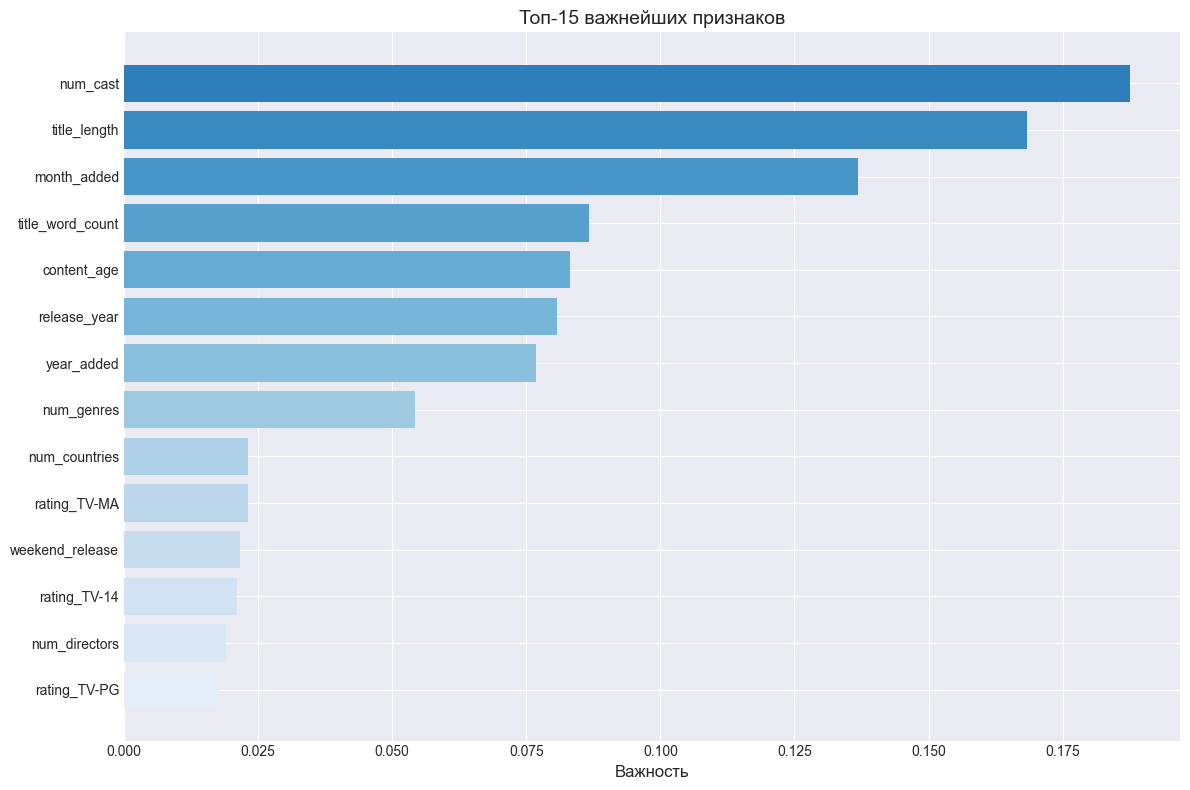

In [26]:
# ОТБОР ПРИЗНАКОВ

rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(X_train, y_train)
feature_importance = pd.DataFrame({
    'признак': X_train.columns,
    'важность': rf_best.feature_importances_
}).sort_values('важность', ascending=False)
print("\nТоп-10 важности признаков (Random Forest):")
print(feature_importance.head(10))

mi_scores = mutual_info_classif(X_train, y_train)
mi_df = pd.DataFrame({
    'признак': X_train.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)
print("\nТоп-10 по Mutual Information:")
print(mi_df.head(10))

X_train_nonneg = X_train.copy()
for col in X_train_nonneg.columns:
    if X_train_nonneg[col].min() < 0:
        X_train_nonneg[col] = X_train_nonneg[col] - X_train_nonneg[col].min()

selector = SelectKBest(score_func=chi2, k=min(15, X_train.shape[1]))
selector.fit(X_train_nonneg, y_train)
selected_features = X_train.columns[selector.get_support()]
print(f"\nТоп-15 по Chi-square: {selected_features.tolist()}")

n_features = min(10, X_train.shape[1])
rfe = RFE(estimator=RandomForestClassifier(random_state=42, n_estimators=50), n_features_to_select=n_features)
rfe.fit(X_train, y_train)
rfe_features = X_train.columns[rfe.support_]
print(f"\nТоп-10 по RFE: {rfe_features.tolist()}")

plt.figure(figsize=(12, 8))
top_15 = feature_importance.head(15)
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(top_15)))
plt.barh(range(len(top_15)), top_15['важность'].values, color=colors)
plt.yticks(range(len(top_15)), top_15['признак'].values)
plt.xlabel('Важность', fontsize=12)
plt.title('Топ-15 важнейших признаков', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Permutation Importance:
Топ-10 по permutation importance:
          Признак  Важность
4        num_cast  0.065036
7      num_genres  0.042446
8      year_added  0.024173
12   rating_TV-MA  0.015108
1     content_age  0.013237
0    release_year  0.012518
11   rating_TV-14  0.012230
13   rating_TV-PG  0.011511
9     month_added  0.007914
3   num_directors  0.006475

Лучшая модель: Random Forest
              precision    recall  f1-score   support

       Movie       0.77      0.95      0.85       963
     TV Show       0.76      0.34      0.47       427

    accuracy                           0.76      1390
   macro avg       0.76      0.65      0.66      1390
weighted avg       0.76      0.76      0.73      1390



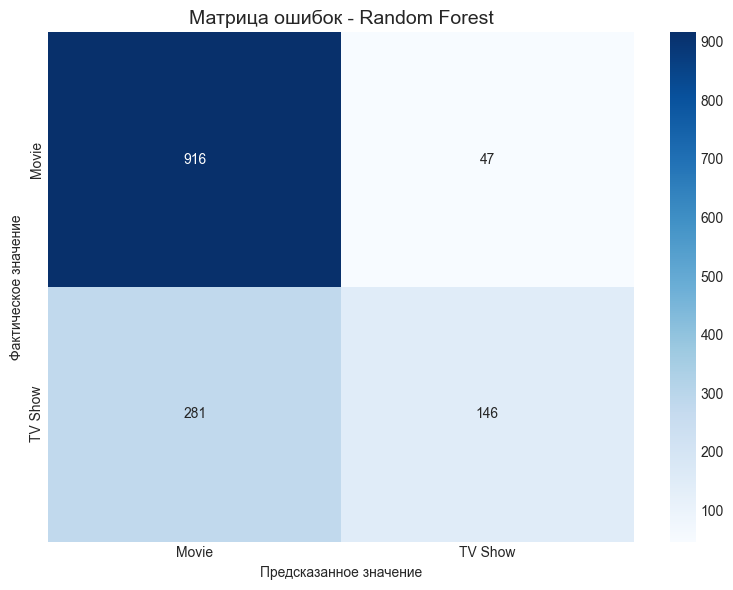

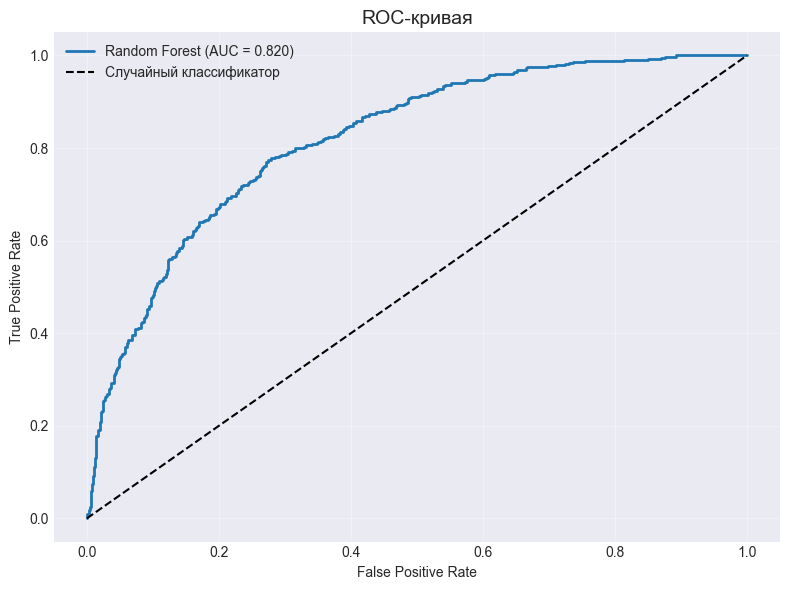


AUC-ROC: 0.8202
Ошибок: 328 из 1390


In [27]:
# ИНТЕРПРЕТАЦИЯ МОДЕЛИ

print("\nPermutation Importance:")
perm_importance = permutation_importance(
    rf_best, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    'Признак': X_test.columns,
    'Важность': perm_importance.importances_mean
}).sort_values('Важность', ascending=False)
print("Топ-10 по permutation importance:")
print(perm_df.head(10))

best_model_name = results_df['accuracy'].idxmax()
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"\nЛучшая модель: {best_model_name}")
print(classification_report(y_test, y_pred_best, target_names=['Movie', 'TV Show']))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])
plt.title(f'Матрица ошибок - {best_model_name}', fontsize=14)
plt.ylabel('Фактическое значение')
plt.xlabel('Предсказанное значение')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_score = roc_auc_score(y_test, y_proba_best)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC-ROC: {auc_score:.4f}")
print(f"Ошибок: {cm[0,1] + cm[1,0]} из {len(y_test)}")